In [1]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Load the data

In [2]:
data = load_breast_cancer()
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

Check the data dimensions

In [3]:
x=data.data
print(x.shape)
y=data.target
print(y.shape)

(569, 30)
(569,)


Get the columns of the data

In [4]:
columns=data.feature_names.copy()
print(columns)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


Put the data in a dataframe for easier visualization and change benign to zero and malignant to 1

In [5]:
df = pd.DataFrame(x, columns=columns)
df['target'] = y
df['target']=df['target'].apply(lambda x: 1 if x==0 else 0)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


split the data into training and testing sets

In [6]:
x=df[columns]
y=df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

fit the model

In [7]:
model=RFC(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

importances=[]
for col, val in zip(columns,model.feature_importances_):
    importances.append((col, val))
importances.sort(key=lambda x: x[1], reverse=True)
print(importances)

Accuracy: 0.9692982456140351

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       148
           1       0.99      0.93      0.95        80

    accuracy                           0.97       228
   macro avg       0.97      0.96      0.97       228
weighted avg       0.97      0.97      0.97       228


Confusion matrix:
[[147   1]
 [  6  74]]
[(np.str_('worst concave points'), np.float64(0.15037955187084348)), (np.str_('mean concave points'), np.float64(0.14097998702509562)), (np.str_('worst area'), np.float64(0.1075759850377543)), (np.str_('mean concavity'), np.float64(0.08110600710216455)), (np.str_('worst perimeter'), np.float64(0.07490526372109346)), (np.str_('mean perimeter'), np.float64(0.065426774286504)), (np.str_('worst radius'), np.float64(0.05308356411248339)), (np.str_('worst concavity'), np.float64(0.043905181832161695)), (np.str_('mean area'), np.float64(0.04019454037403082)), (np.str_('mean radi

perform some predictions

In [8]:
predictions=model.predict(x_test)
for val in predictions[0:10]:
    print("{:.0f}\t".format(val), end="")
print()
for val in y_test[0:10]:
    print("{:.0f}\t".format(val), end="")
print()
acc=accuracy_score(y_test, predictions)
print("Accuracy: {:.2f}".format(acc))

0	1	1	0	0	1	1	1	1	0	
0	1	1	0	0	1	1	1	0	0	
Accuracy: 0.97


Apply Permutation Feature Importance

In [9]:
result = permutation_importance(model, x_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
dfSummary=pd.DataFrame({'Variable':columns, 'importance':result.importances_mean, 'coeff_lb': result.importances_std, 'coeff_ub':result.importances_std})

sort the values by importance

In [10]:
dfSorted=dfSummary.sort_values(by="importance", ascending=False)
dfSorted.head(30)

,Variable,importance,coeff_lb,coeff_ub
21,worst texture,0.009649,0.004724,0.004724
23,worst area,0.006140,0.007126,0.007126
22,worst perimeter,0.005702,0.008999,0.008999
1,mean texture,0.005263,0.004297,0.004297
27,worst concave points,0.004825,0.009294,0.009294
4,mean smoothness,0.002632,0.002909,0.002909
0,mean radius,0.001754,0.002149,0.002149
28,worst symmetry,0.000439,0.002362,0.002362
17,concave points error,0.000000,0.000000,0.000000
24,worst smoothness,-0.000439,0.002362,0.002362


Plot the ICE and PDP plots

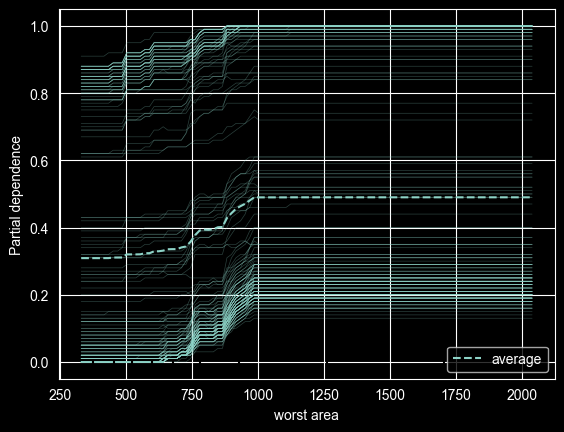

In [11]:
PartialDependenceDisplay.from_estimator(model, x_test, ["worst area"],feature_names=columns, kind='both')
plt.show()